In [1]:
# 导入系统、数值计算、数据处理相关库
import os
import numpy as np
import pandas as pd
# 导入gzip压缩文件读取库
import gzip
# 开启matplotlib内联绘图，图像直接展示在单元格中
%matplotlib inline
# 导入绘图相关库
import matplotlib
import matplotlib.pyplot as plt

# 自定义函数：将一维像素向量还原为28*28灰度图像并展示
def showImage(data):
    # 将784维一维特征重塑为28行28列的像素矩阵
    some_article_image = data.reshape(28, 28)
    # 绘制灰度图像，采用最近邻插值保证图像清晰度
    plt.imshow(some_article_image, cmap = matplotlib.cm.binary, interpolation="nearest")
    # 隐藏坐标轴，让图像展示更简洁
    plt.axis("off")
    # 弹出图像窗口
    plt.show()

数据集路径配置

In [2]:
# 定义训练集、测试集图像与标签文件的本地绝对路径
filePath_train_set = r'D:\机器学习\train-images-idx3-ubyte.gz'
filePath_train_label = r'D:\机器学习\train-labels-idx1-ubyte.gz'

filePath_test_set = r'D:\机器学习\t10k-images-idx3-ubyte.gz'
filePath_test_label = r'D:\机器学习\t10k-labels-idx1-ubyte.gz'

# 打印路径信息并校验文件是否存在，提前排查路径错误、文件缺失问题
print("标签文件路径:", filePath_train_label)
print("检查文件是否存在", os.path.exists(filePath_train_label))
print("当前代码运行目录:", os.getcwd())

标签文件路径: D:\机器学习\train-labels-idx1-ubyte.gz
检查文件是否存在 True
当前代码运行目录: C:\Users\Liang


预处理

In [3]:
# 读取训练集标签文件，跳过前8字节文件头部信息，解析为uint8类型数组
with gzip.open(filePath_train_label, 'rb') as trainLbpath:
     trainLabel = np.frombuffer(trainLbpath.read(), dtype=np.uint8, offset=8)

# 读取训练集图像文件，跳过前16字节文件头部信息，重塑为【样本数×784维特征】矩阵
with gzip.open(filePath_train_set, 'rb') as trainSetpath:
     trainSet = np.frombuffer(trainSetpath.read(), dtype=np.uint8, offset=16).reshape(len(trainLabel), 784)

# 读取测试集标签文件
with gzip.open(filePath_test_label, 'rb') as testLbpath:
     testLabel = np.frombuffer(testLbpath.read(), dtype=np.uint8, offset=8)

# 读取测试集图像文件，维度与训练集保持一致
with gzip.open(filePath_test_set, 'rb') as testSetpath:
     testSet = np.frombuffer(testSetpath.read(), dtype=np.uint8, offset=16).reshape(len(testLabel), 784)

# 打印标签数据类型
print("标签数据类型:", type(testLabel))
# 打印训练集图像、训练集标签、测试集图像、测试集标签的维度
print("训练集图像维度:", trainSet.shape)
print("训练集标签维度:", trainLabel.shape)
print("测试集图像维度:", testSet.shape)
print("测试集标签维度:", testLabel.shape)

# 统一命名训练集、测试集特征与标签，符合机器学习常规命名规范
X_train, X_test, y_train, y_test = trainSet, testSet, trainLabel, testLabel

# 再次打印维度，二次校验数据解析是否正常
print("训练集特征维度:", X_train.shape)
print("训练集标签维度:", y_train.shape)
print("测试集特征维度:", X_test.shape)
print("测试集标签维度:", y_test.shape)

标签数据类型: <class 'numpy.ndarray'>
训练集图像维度: (60000, 784)
训练集标签维度: (60000,)
测试集图像维度: (10000, 784)
测试集标签维度: (10000,)
训练集特征维度: (60000, 784)
训练集标签维度: (60000,)
测试集特征维度: (10000, 784)
测试集标签维度: (10000,)


In [5]:
# 设置随机种子，保证多次运行实验结果完全一致
np.random.seed(42)
# 生成随机索引，打乱60000条训练样本顺序，避免数据集有序排列导致模型偏置
shuffle_index = np.random.permutation(60000)
# 根据随机索引重新排序训练集特征与标签
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]

# 导入特征标准化工具
from sklearn.preprocessing import StandardScaler
# 初始化标准化器（Z-score标准化）
scaler = StandardScaler()
# 拟合训练集并完成标准化，仅用于线性模型（逻辑回归）
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

逻辑回归模型

C:\Users\Liang\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


训练集首个样本真实标签: 1
逻辑回归预测标签: 4


C:\Users\Liang\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


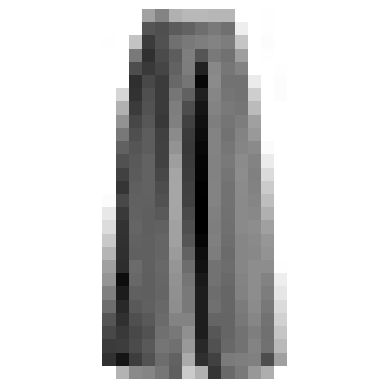

===== 逻辑回归 - 训练集评估结果 =====
准确率:  0.8816
精确率:  0.8806192586991111
召回率:  0.8816
F1分数:  0.8809005902297699


In [6]:
# 导入模型评估指标库
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 导入逻辑回归模型
from sklearn.linear_model import LogisticRegression

# 初始化Softmax多分类逻辑回归模型
# multi_class="multinomial"：启用Softmax多分类；solver="lbfgs"：选用拟牛顿优化器
# C=10：L2正则化系数；max_iter=5000：最大迭代次数；random_state=42：固定随机种子
log_clf = LogisticRegression(multi_class="multinomial", solver="saga", C=10, random_state=42,max_iter=2500)
# 使用标准化后的训练集训练模型
log_clf.fit(X_train_scaled, y_train)

# 选取第一个训练样本，重塑为二维矩阵（模型要求输入格式），完成单样本预测
y_train_predict = log_clf.predict(X_train[0].reshape(1, -1))
# 打印该样本真实标签、预测标签
print("训练集首个样本真实标签:", y_train[0])
print("逻辑回归预测标签:", y_train_predict[0])
# 展示该样本图像
showImage(X_train[0])

# 使用训练好的模型对全部训练集做预测
y_train_predict = log_clf.predict(X_train_scaled)

# 计算四大分类指标（加权平均，适配多分类任务）
log_accuracy = accuracy_score(y_train, y_train_predict)
log_precision = precision_score(y_train, y_train_predict, average='weighted')
log_recall = recall_score(y_train, y_train_predict, average='weighted')
log_f1_score = f1_score(y_train, y_train_predict, average='weighted')

# 打印逻辑回归在训练集上的各项指标
print("===== 逻辑回归 - 训练集评估结果 =====")
print("准确率: ", log_accuracy)
print("精确率: ", log_precision)
print("召回率: ", log_recall)
print("F1分数: ", log_f1_score)

随机森林模型

训练集首个样本真实标签: 1
随机森林预测标签: 3


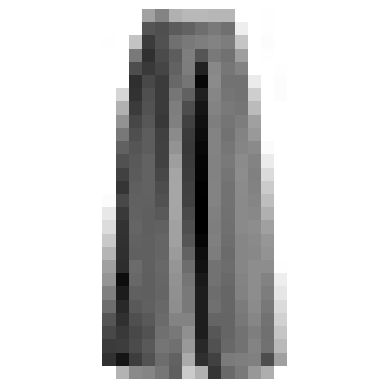

===== 随机森林 - 训练集评估结果 =====
准确率:  0.8752666666666666
精确率:  0.8767933527395633
召回率:  0.8752666666666666
F1分数:  0.8734414243920836


In [7]:
# 导入随机森林分类模型
from sklearn.ensemble import RandomForestClassifier

# 初始化随机森林模型
# n_estimators=12：共12棵决策树；max_depth=10：限制树最大深度，防止过拟合
rnd_clf = RandomForestClassifier(n_estimators=12, max_depth=10, random_state=42)

# 随机森林属于树模型，不受特征量纲影响，直接使用原始训练集训练
rnd_clf.fit(X_train, y_train)

# 对同一个训练样本做预测演示
y_train_predict = rnd_clf.predict(X_train[0].reshape(1, -1))
print("训练集首个样本真实标签:", y_train[0])
print("随机森林预测标签:", y_train_predict[0])
# 再次展示该样本图像
showImage(X_train[0])

# 对全部训练集完成预测
y_train_predict = rnd_clf.predict(X_train)

# 计算随机森林的四项分类指标
rnd_accuracy = accuracy_score(y_train, y_train_predict)
rnd_precision = precision_score(y_train, y_train_predict, average='weighted')
rnd_recall = recall_score(y_train, y_train_predict, average='weighted')
rnd_f1_score = f1_score(y_train, y_train_predict, average='weighted')

# 打印随机森林在训练集上的各项指标
print("===== 随机森林 - 训练集评估结果 =====")
print("准确率: ", rnd_accuracy)
print("精确率: ", rnd_precision)
print("召回率: ", rnd_recall)
print("F1分数: ", rnd_f1_score)

可视化测试

C:\Users\Liang\AppData\Local\Temp\ipykernel_22124\1478108732.py:41: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Liang\AppData\Local\Temp\ipykernel_22124\1478108732.py:41: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Liang\AppData\Local\Temp\ipykernel_22124\1478108732.py:41: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Liang\AppData\Local\Temp\ipykernel_22124\1478108732.py:41: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Liang\AppData\Local\Temp\ipykernel_22124\1478108732.py:41: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Liang\AppData\Local\Temp\ipykernel_22124\1478108732.py:41: UserWarning: Glyph 30701 (\N{CJK UNIFI

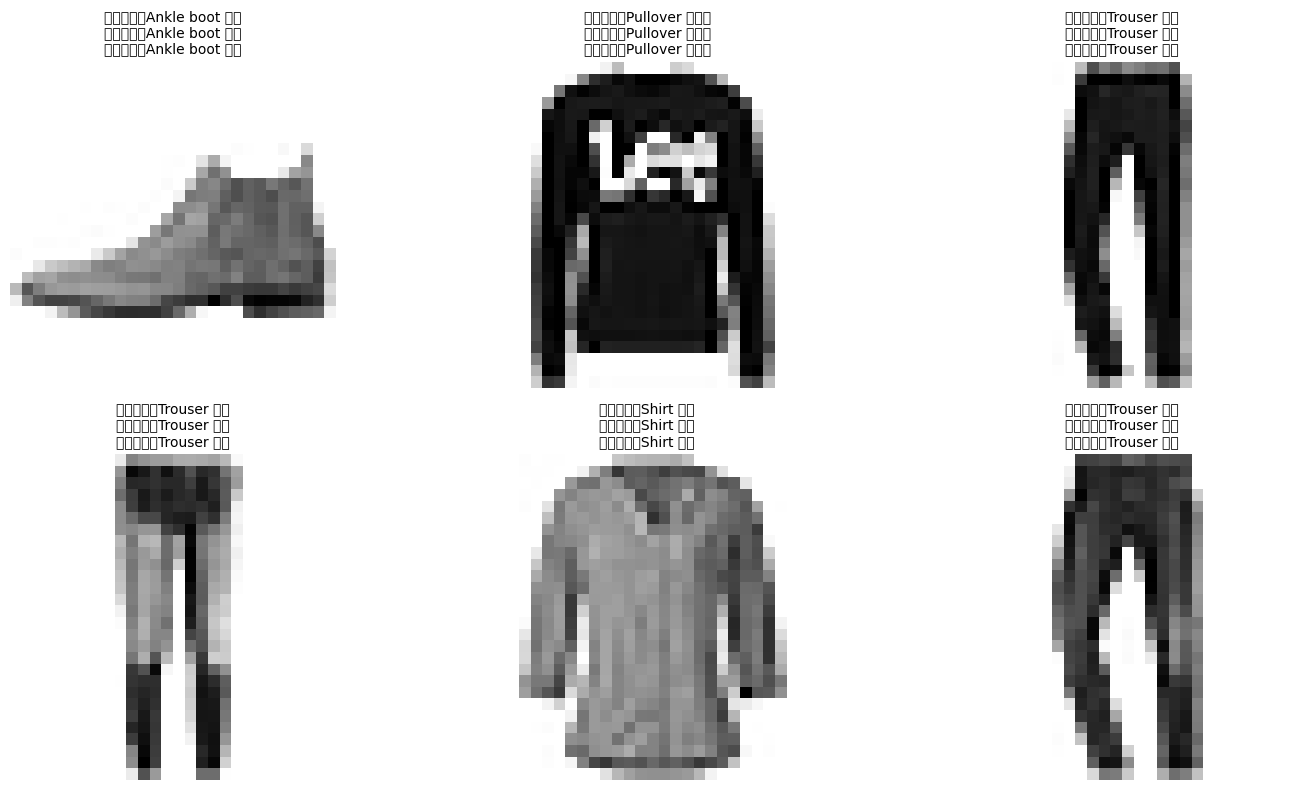


===== 单个测试样本详细识别结果 =====
样本真实标签：9 → Ankle boot 短靴
逻辑回归预测标签：9 → Ankle boot 短靴
随机森林预测标签：9 → Ankle boot 短靴


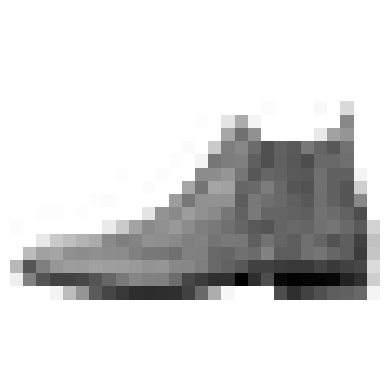

In [8]:
# 定义服饰类别映射（数字标签 → 真实服饰名称，提升可视化可读性）
label_name = {
    0: "T-shirt/top 上衣",
    1: "Trouser 裤子",
    2: "Pullover 套头衫",
    3: "Dress 连衣裙",
    4: "Coat 外套",
    5: "Sandal 凉鞋",
    6: "Shirt 衬衫",
    7: "Sneaker 运动鞋",
    8: "Bag 背包",
    9: "Ankle boot 短靴"
}

# 选取测试集中前6个样本做可视化预测展示
sample_num = 6
test_samples = X_test[:sample_num]
test_true_label = y_test[:sample_num]

# 逻辑回归预测（测试集需先标准化）
test_scaled = scaler.transform(test_samples.astype(np.float64))
log_pred_label = log_clf.predict(test_scaled)

# 随机森林预测（直接使用原始像素）
rf_pred_label = rnd_clf.predict(test_samples)

# 创建画布，批量展示测试样本 + 识别结果
plt.figure(figsize=(15, 8))
for i in range(sample_num):
    plt.subplot(2, 3, i+1)
    # 绘制测试图像
    img = test_samples[i].reshape(28,28)
    plt.imshow(img, cmap=matplotlib.cm.binary)
    plt.axis("off")
    # 拼接真实标签、两种模型预测标签
    true_text = f"真实类别：{label_name[test_true_label[i]]}"
    log_text = f"逻辑回归：{label_name[log_pred_label[i]]}"
    rf_text = f"随机森林：{label_name[rf_pred_label[i]]}"
    plt.title(f"{true_text}\n{log_text}\n{rf_text}", fontsize=10)

plt.tight_layout()
plt.show()

# 单独抽查1个测试样本，单图展示
print("\n===== 单个测试样本详细识别结果 =====")
test_idx = 0  # 可修改下标查看不同样本
single_test_img = X_test[test_idx]
single_true = y_test[test_idx]
single_log_pred = log_clf.predict(scaler.transform(single_test_img.reshape(1,-1)))[0]
single_rf_pred = rnd_clf.predict(single_test_img.reshape(1,-1))[0]

print(f"样本真实标签：{single_true} → {label_name[single_true]}")
print(f"逻辑回归预测标签：{single_log_pred} → {label_name[single_log_pred]}")
print(f"随机森林预测标签：{single_rf_pred} → {label_name[single_rf_pred]}")
showImage(single_test_img)

In [ ]:
# 导入交叉验证、预测工具与混淆矩阵
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix

# 自定义函数：输出交叉验证得分、平均分、标准差（评估模型精度与稳定性）
def display_scores(scores):
    print("每轮交叉验证得分:", scores)
    print("平均得分:", scores.mean())
    print("得分标准差:", scores.std())

# ===================== 逻辑回归 3折交叉验证 =====================
# 重新初始化逻辑回归模型
log_clf = LogisticRegression(multi_class="multinomial", solver="saga", C=10, random_state=42,max_iter=2500)
# 3折交叉验证，评估指标为准确率
log_cv_scores = cross_val_score(log_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")
# 打印交叉验证统计结果
display_scores(log_cv_scores)
# 记录交叉验证平均准确率
log_cv_accuracy = log_cv_scores.mean()

# 交叉验证方式生成全训练集预测结果
y_train_pred = cross_val_predict(log_clf, X_train_scaled, y_train, cv=3)
# 生成混淆矩阵（本实验仅计算，不打印）
confusion_matrix(y_train, y_train_pred)
# 计算交叉验证下的四项指标
log_cv_precision = precision_score(y_train, y_train_pred, average='weighted')
log_cv_recall = recall_score(y_train, y_train_pred, average='weighted')
log_cv_f1_score = f1_score(y_train, y_train_pred, average='weighted')

# 打印逻辑回归交叉验证指标
print("===== 逻辑回归 - 3折交叉验证结果 =====")
print("交叉验证准确率: ", log_cv_accuracy)
print("交叉验证精确率: ", log_cv_precision)
print("交叉验证召回率: ", log_cv_recall)
print("交叉验证F1分数: ", log_cv_f1_score)

# ===================== 随机森林 3折交叉验证 =====================
# 重新初始化随机森林模型
rnd_clf = RandomForestClassifier(n_estimators=12, max_depth=10, random_state=42)
# 3折交叉验证
rnd_cv_scores = cross_val_score(rnd_clf, X_train, y_train, cv=3, scoring="accuracy")
display_scores(rnd_cv_scores)
rnd_cv_accuracy = rnd_cv_scores.mean()

# 交叉验证预测
y_train_pred = cross_val_predict(rnd_clf, X_train, y_train, cv=3)
confusion_matrix(y_train, y_train_pred)
# 计算指标
rnd_cv_precision = precision_score(y_train, y_train_pred, average='weighted')
rnd_cv_recall = recall_score(y_train, y_train_pred, average='weighted')
rnd_cv_f1_score = f1_score(y_train, y_train_pred, average='weighted')

# 打印随机森林交叉验证指标
print("===== 随机森林 - 3折交叉验证结果 =====")
print("交叉验证准确率: ", rnd_cv_accuracy)
print("交叉验证精确率: ", rnd_cv_precision)
print("交叉验证召回率: ", rnd_cv_recall)
print("交叉验证F1分数: ", rnd_cv_f1_score)

# 集中汇总两种模型交叉验证结果，方便对比查看
print("\n========== 模型结果汇总 ==========")
print("--- Softmax逻辑回归 ---")
display_scores(log_cv_scores)
print("交叉验证准确率:", log_cv_accuracy)
print("交叉验证精确率:", log_cv_precision)
print("交叉验证召回率:", log_cv_recall)
print("交叉验证F1分数:", log_cv_f1_score)

print("\n--- 随机森林 ---")
display_scores(rnd_cv_scores)
print("交叉验证准确率:", rnd_cv_accuracy)
print("交叉验证精确率:", rnd_cv_precision)
print("交叉验证召回率:", rnd_cv_recall)
print("交叉验证F1分数:", rnd_cv_f1_score)